# Lab 4: Fuzzy C-Means (FCM) and DBSCAN Clustering

This notebook provides a complete, structured, and standalone implementation of advanced clustering algorithms on the benchmark Iris dataset:
1. **Fuzzy C-Means (FCM)**: Soft partitioning allowing samples to belong to multiple clusters with graded membership degrees ($u_{ij} \in [0, 1]$).
2. **DBSCAN**: Density-Based Spatial Clustering of Applications with Noise, discovering clusters of arbitrary shapes and identifying outliers/noise points ($label = -1$).

### Key Workflow Highlights
- **Exploratory Data Analysis (EDA)**: Feature distributions (Histograms + KDE) and correlation analysis.
- **Pure NumPy Vectorized FCM**: Self-contained mathematical implementation of Bezdek's algorithm ($J_m$ objective, soft membership matrix updates, centroid convergence).
- **FCM Parameter Optimization**: Sweeps across cluster counts ($c \in [2, 10]$) and fuzziness parameter $m$.
- **DBSCAN Parameter Calibration**: Empirical k-nearest-neighbors distance elbow graph to select $\epsilon$, followed by a grid search over $\epsilon$ and `min_samples`.
- **Hungarian Label Alignment**: Bipartite optimal matching (`linear_sum_assignment`) aligning unsupervised cluster IDs with ground truth classes while handling DBSCAN noise points.
- **Comprehensive Evaluation**: Unsupervised quality metrics (Silhouette, Davies-Bouldin, Calinski-Harabasz) and supervised classification errors (MAE, MSE, RMSE, ARI, NMI).
- **Rich Visualizations**: 2D feature scatter plots with centroids, 2D PCA projections, FCM soft membership distributions, DBSCAN density breakdowns, and confusion matrix heatmaps.
- **Simplicity**: No train/dev/test splits; direct, transparent analysis across all 150 benchmark samples.


## 1. Imports and Setup
We import core scientific and machine learning libraries. For Fuzzy C-Means, we implement a vectorized class from scratch using pure NumPy and SciPy, ensuring no external uninstalled packages are required.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    adjusted_rand_score,
    normalized_mutual_info_score,
    accuracy_score
)
from scipy.optimize import linear_sum_assignment

# Plotting configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 12

print("Environment and libraries successfully loaded!")


Environment and libraries successfully loaded!


## 2. Dataset Loading & Minimal Preprocessing
We load the classic Fisher's Iris dataset containing 150 samples across 3 biological species (`setosa`, `versicolor`, `virginica`) measured on 4 continuous morphological features.
Because both Fuzzy C-Means (Euclidean distance to centroids) and DBSCAN (neighborhood radius $\epsilon$) are distance-sensitive, we standardize all features to have zero mean and unit variance using `StandardScaler`.


In [2]:
# Load Iris dataset
iris = load_iris()
feature_names = iris.feature_names
target_names = iris.target_names
X_raw = iris.data
y = iris.target

# Create structured DataFrame
df = pd.DataFrame(X_raw, columns=feature_names)
df['species'] = [target_names[i] for i in y]

# Standardize features (mean=0, variance=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Dataset shape: {X_scaled.shape}")
print(f"Features: {feature_names}")
print(f"Target classes: {list(target_names)}")
print(f"Class distribution: {dict(pd.Series(y).value_counts().sort_index())}")
print(f"Feature means after scaling: {np.round(X_scaled.mean(axis=0), 4)}")
print(f"Feature stds after scaling: {np.round(X_scaled.std(axis=0), 4)}")
df.head()


Dataset shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Class distribution: {0: np.int64(50), 1: np.int64(50), 2: np.int64(50)}
Feature means after scaling: [-0. -0. -0. -0.]
Feature stds after scaling: [1. 1. 1. 1.]
Out[0]: 
   sepal length (cm)  sepal width (cm)  ...  petal width (cm)  species
0                5.1               3.5  ...               0.2   setosa
1                4.9               3.0  ...               0.2   setosa
2                4.7               3.2  ...               0.2   setosa
3                4.6               3.1  ...               0.2   setosa
4                5.0               3.6  ...               0.2   setosa

[5 rows x 5 columns]


## 3. Exploratory Data Analysis (EDA)
Before clustering, we examine feature distributions, skewness, and pairwise correlation structure to understand natural separability.


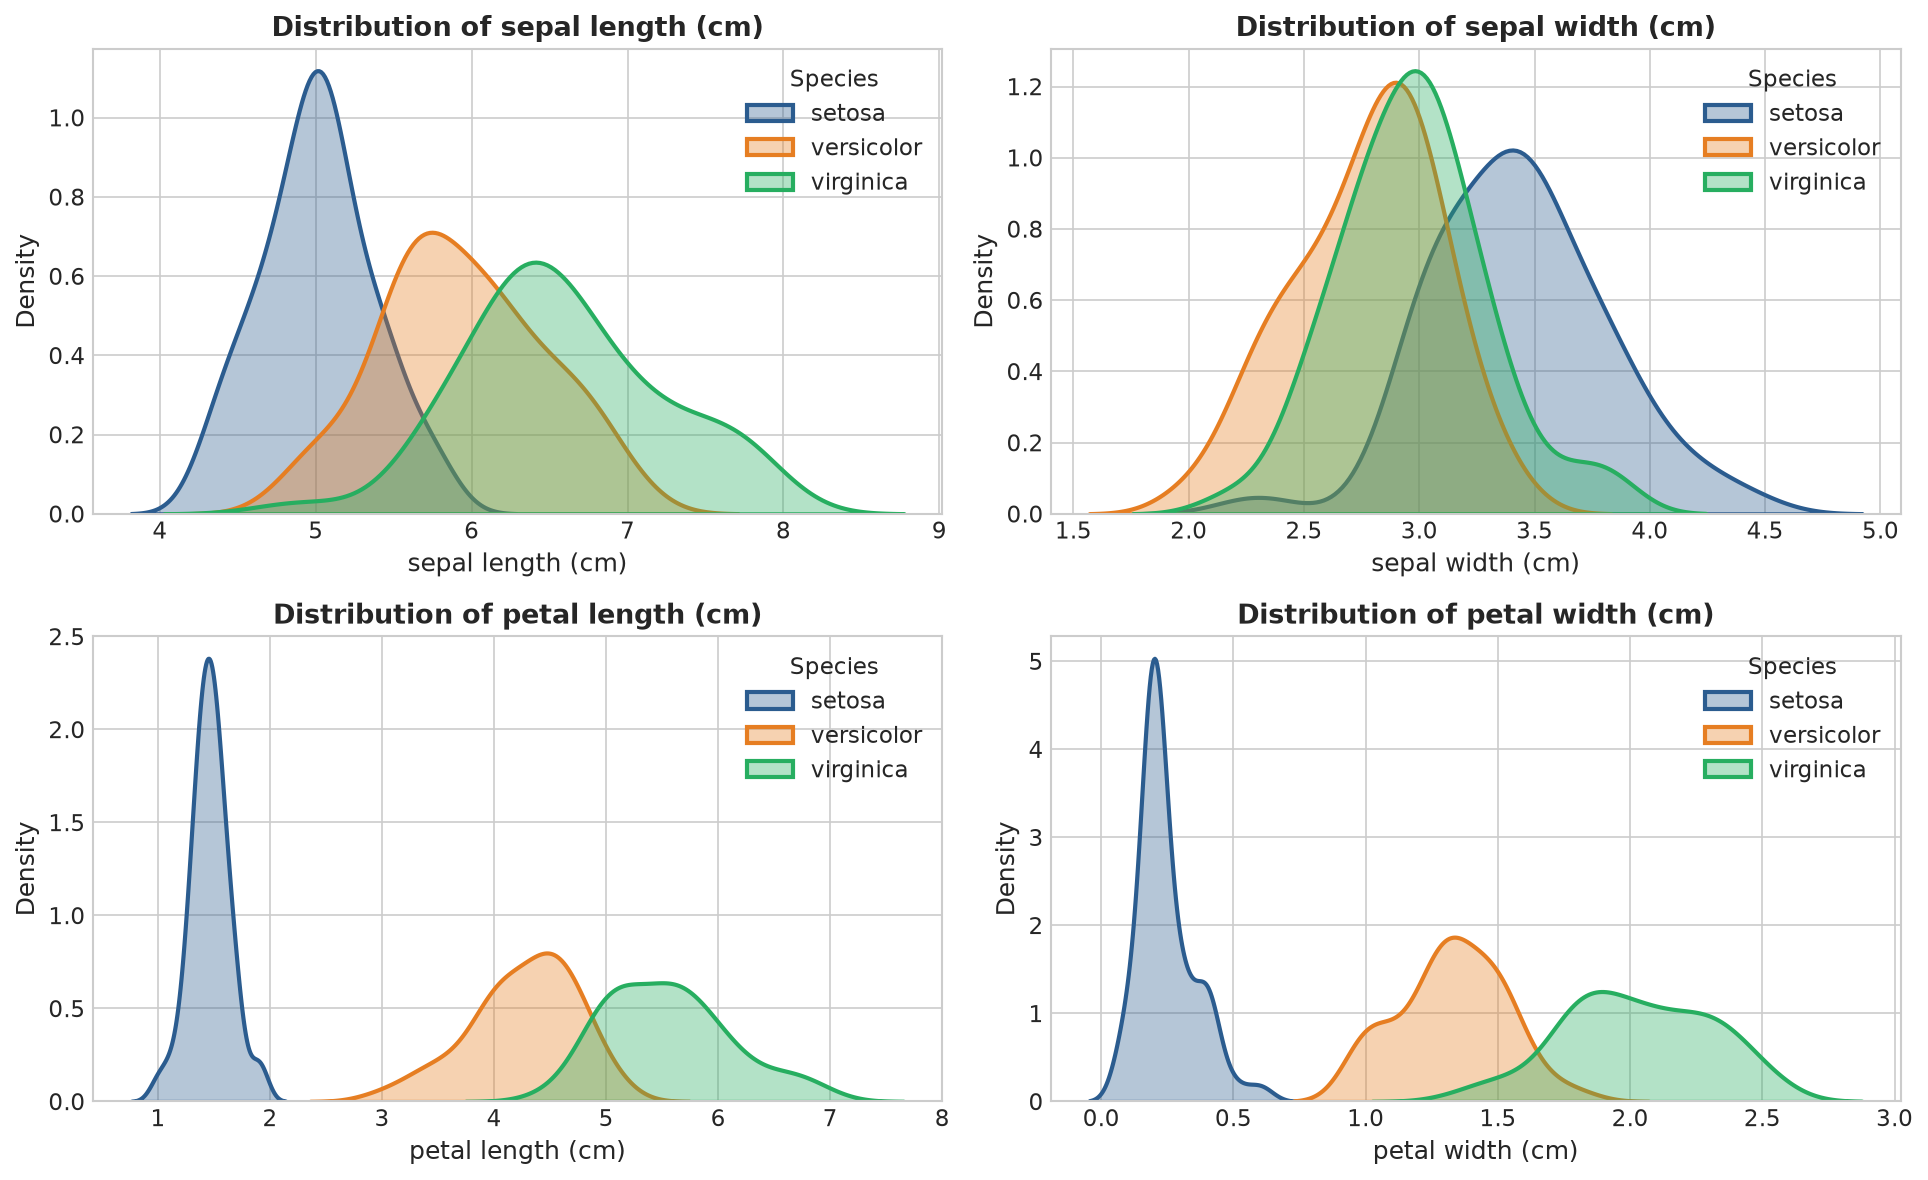

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
palette = ['#2b5c8f', '#e67e22', '#27ae60']

for idx, (col, ax) in enumerate(zip(feature_names, axes.flatten())):
    for class_idx, class_name in enumerate(target_names):
        subset = df[df['species'] == class_name][col]
        sns.kdeplot(subset, ax=ax, label=class_name, color=palette[class_idx], fill=True, alpha=0.35, linewidth=2)
    ax.set_title(f"Distribution of {col}", fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend(title="Species")

plt.tight_layout()
plt.show()


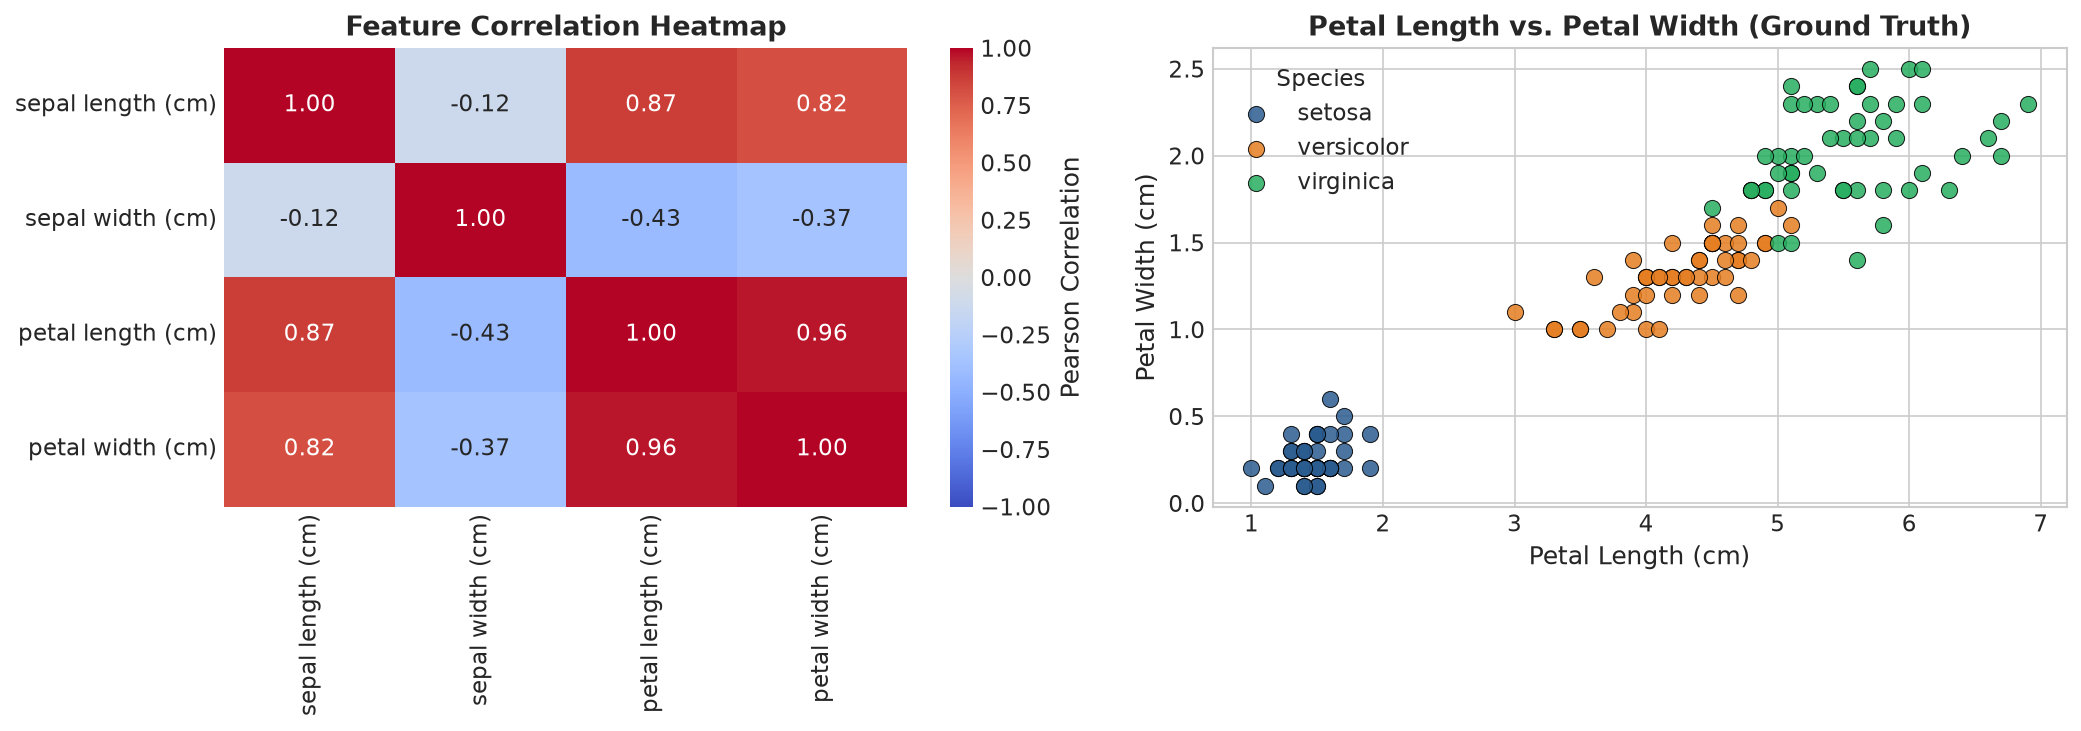

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 3.1 Feature Correlation Heatmap
corr = df[feature_names].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0], cbar_kws={'label': 'Pearson Correlation'})
axes[0].set_title("Feature Correlation Heatmap", fontweight='bold')

# 3.2 Bivariate Scatter: Petal Length vs. Petal Width
for class_idx, class_name in enumerate(target_names):
    subset = df[df['species'] == class_name]
    axes[1].scatter(subset['petal length (cm)'], subset['petal width (cm)'], 
                    label=class_name, color=palette[class_idx], s=60, alpha=0.85, edgecolors='k', linewidth=0.5)

axes[1].set_title("Petal Length vs. Petal Width (Ground Truth)", fontweight='bold')
axes[1].set_xlabel("Petal Length (cm)")
axes[1].set_ylabel("Petal Width (cm)")
axes[1].legend(title="Species")

plt.tight_layout()
plt.show()


## 4. Fuzzy C-Means (FCM) Implementation & Optimization
### 4.1 Theoretical Formulation
In contrast to crisp K-Means where each data point strictly belongs to exactly one cluster, **Fuzzy C-Means (FCM)** allows soft memberships $u_{ij} \in [0, 1]$ representing the degree of belonging of sample $i$ to cluster $j$, with $\sum_{j=1}^c u_{ij} = 1$.

The algorithm minimizes the objective function:
$$J_m = \sum_{i=1}^N \sum_{j=1}^c u_{ij}^m \|x_i - v_j\|^2$$

where:
- $N$ is the number of samples ($N=150$).
- $c$ is the number of clusters ($c=3$).
- $m > 1$ is the fuzziness exponent (standard default $m=2.0$). As $m \to 1$, FCM approaches hard K-Means.
- $v_j$ is the centroid of cluster $j$:
$$v_j = \frac{\sum_{i=1}^N u_{ij}^m x_i}{\sum_{i=1}^N u_{ij}^m}$$
- The membership update at each iteration is:
$$u_{ij} = \frac{1}{\sum_{k=1}^c \left(\frac{\|x_i - v_j\|}{\|x_i - v_k\|}\right)^{\frac{2}{m-1}}}$$

Below is our fully vectorized NumPy implementation.


In [5]:
class FuzzyCMeans:
    """
    Vectorized Fuzzy C-Means (FCM) Clustering in pure NumPy.
    
    Parameters
    ----------
    n_clusters : int, default=3
        The number of clusters to form.
    m : float, default=2.0
        Fuzziness weighting exponent (m > 1).
    max_iter : int, default=300
        Maximum number of iterations.
    tol : float, default=1e-5
        Convergence threshold for change in membership matrix.
    random_state : int, default=42
        Random seed for reproducibility.
    """
    def __init__(self, n_clusters=3, m=2.0, max_iter=300, tol=1e-5, random_state=42):
        self.n_clusters = n_clusters
        self.m = m
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.cluster_centers_ = None
        self.u_ = None
        self.labels_ = None
        self.cost_history_ = []

    def fit(self, X):
        rng = np.random.RandomState(self.random_state)
        n_samples, n_features = X.shape
        
        # Step 1: Initialize random membership matrix and normalize rows to sum to 1.0
        u = rng.uniform(size=(n_samples, self.n_clusters))
        u = u / np.sum(u, axis=1, keepdims=True)
        
        self.cost_history_ = []
        power = 2.0 / (self.m - 1.0)
        
        for iteration in range(self.max_iter):
            u_old = u.copy()
            
            # Step 2: Compute cluster centroids v_j = sum(u_ij^m * x_i) / sum(u_ij^m)
            u_m = u ** self.m
            centers = (u_m.T @ X) / np.sum(u_m.T, axis=1, keepdims=True)
            
            # Step 3: Compute Euclidean distances ||x_i - v_j||
            dists = np.linalg.norm(X[:, np.newaxis, :] - centers[np.newaxis, :, :], axis=2)
            dists = np.fmax(dists, 1e-10)  # Avoid division by zero
            
            # Step 4: Update membership matrix u_ij
            inv_dists = dists ** (-power)
            u = inv_dists / np.sum(inv_dists, axis=1, keepdims=True)
            
            # Compute objective function J_m
            cost = np.sum((u ** self.m) * (dists ** 2))
            self.cost_history_.append(cost)
            
            # Check convergence
            if np.max(np.abs(u - u_old)) < self.tol:
                break
                
        self.cluster_centers_ = centers
        self.u_ = u
        self.labels_ = np.argmax(u, axis=1)
        return self

    def predict_proba(self, X):
        """Compute soft membership probabilities for new samples."""
        dists = np.linalg.norm(X[:, np.newaxis, :] - self.cluster_centers_[np.newaxis, :, :], axis=2)
        dists = np.fmax(dists, 1e-10)
        power = 2.0 / (self.m - 1.0)
        inv_dists = dists ** (-power)
        return inv_dists / np.sum(inv_dists, axis=1, keepdims=True)

    def predict(self, X):
        """Assign crisp labels via argmax."""
        return np.argmax(self.predict_proba(X), axis=1)

print("FuzzyCMeans class definition ready!")


FuzzyCMeans class definition ready!


### 4.2 FCM Hyperparameter Tuning: Objective Cost & Silhouette vs. Cluster Count $c$
To find the optimal cluster count $c$, we perform a hyperparameter sweep over $c \in [2, 10]$. We examine the **FCM Objective Function ($J_m$) Elbow Curve** and the **Silhouette Score Curve**.


FCM Hyperparameter Sweep Summary:
Out[0]: 
   Clusters (c)  Final Cost (J_m)  Silhouette Score  Davies-Bouldin
0             2            181.54            0.5818          0.5933
1             3            100.42            0.4584          0.8340
2             4             73.76            0.4017          0.9570
3             5             60.34            0.3448          1.2394
4             6             43.37            0.2774          1.2287
5             7             36.78            0.2818          1.1585
6             8             30.80            0.3052          1.0086
7             9             28.20            0.3048          1.0639
8            10             23.84            0.3277          0.9544


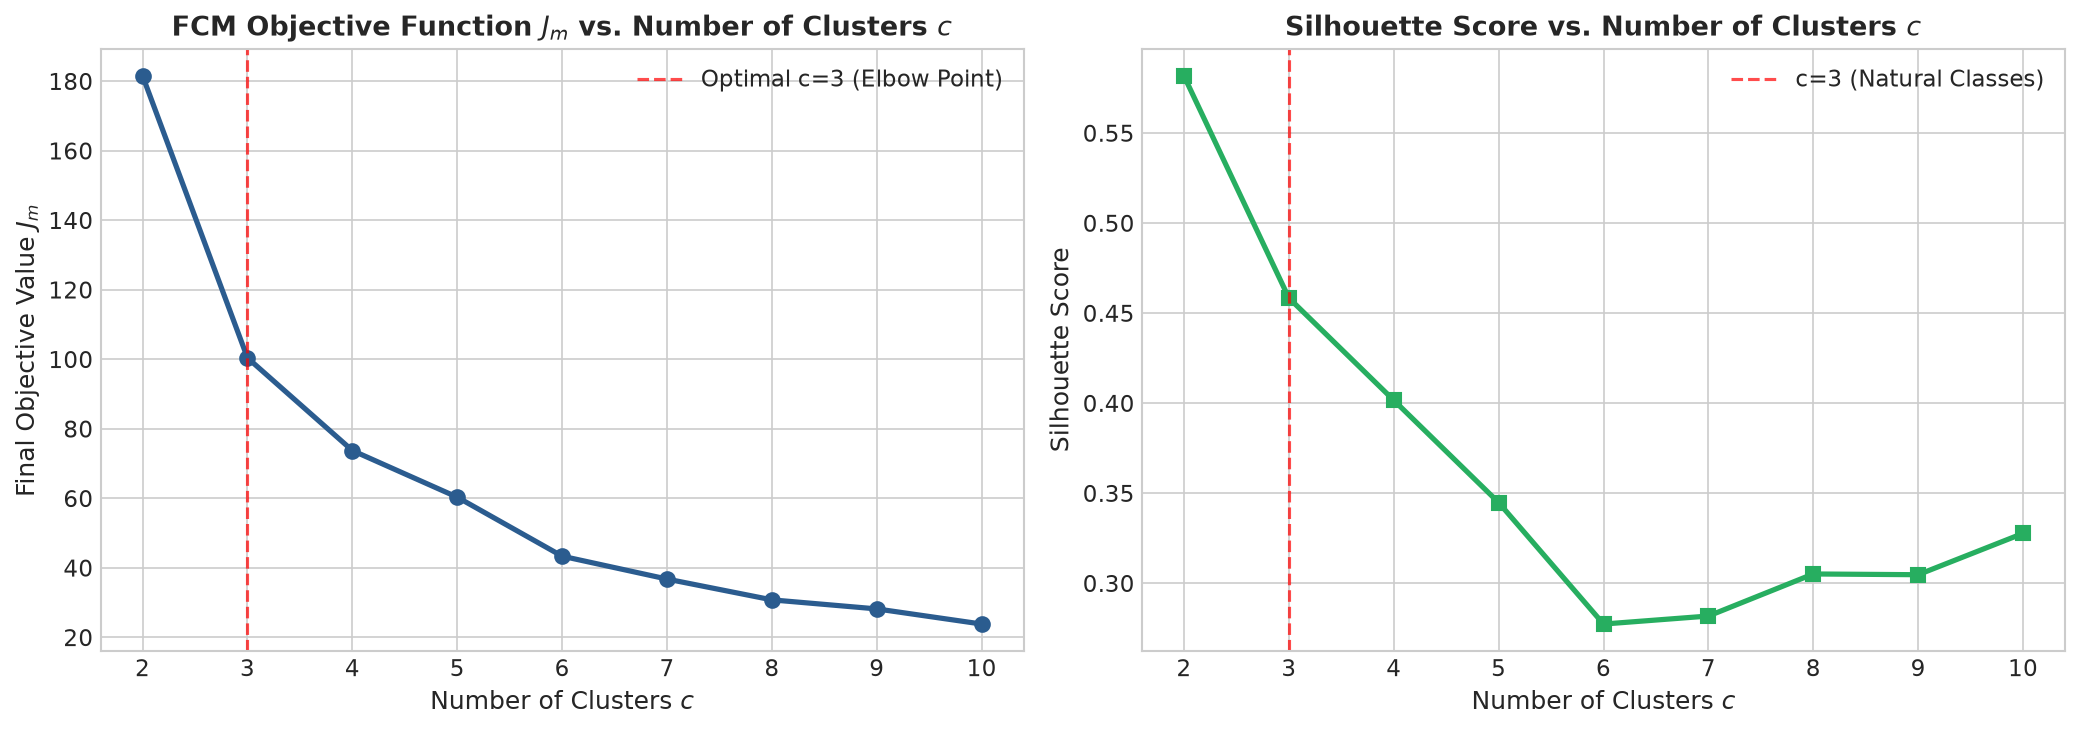

In [6]:
c_values = list(range(2, 11))
fcm_costs = []
fcm_silhouettes = []
fcm_db_scores = []

for c in c_values:
    model = FuzzyCMeans(n_clusters=c, m=2.0, random_state=42).fit(X_scaled)
    fcm_costs.append(model.cost_history_[-1])
    fcm_silhouettes.append(silhouette_score(X_scaled, model.labels_))
    fcm_db_scores.append(davies_bouldin_score(X_scaled, model.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 4.2.1 Objective Cost Elbow Plot
axes[0].plot(c_values, fcm_costs, marker='o', color='#2b5c8f', linewidth=2.5, markersize=7)
axes[0].set_title("FCM Objective Function $J_m$ vs. Number of Clusters $c$", fontweight='bold')
axes[0].set_xlabel("Number of Clusters $c$")
axes[0].set_ylabel("Final Objective Value $J_m$")
axes[0].set_xticks(c_values)
axes[0].axvline(x=3, color='r', linestyle='--', alpha=0.7, label='Optimal c=3 (Elbow Point)')
axes[0].legend()

# 4.2.2 Silhouette Score Curve
axes[1].plot(c_values, fcm_silhouettes, marker='s', color='#27ae60', linewidth=2.5, markersize=7)
axes[1].set_title("Silhouette Score vs. Number of Clusters $c$", fontweight='bold')
axes[1].set_xlabel("Number of Clusters $c$")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(c_values)
axes[1].axvline(x=3, color='r', linestyle='--', alpha=0.7, label='c=3 (Natural Classes)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Display tuning summary table
fcm_sweep_df = pd.DataFrame({
    'Clusters (c)': c_values,
    'Final Cost (J_m)': np.round(fcm_costs, 2),
    'Silhouette Score': np.round(fcm_silhouettes, 4),
    'Davies-Bouldin': np.round(fcm_db_scores, 4)
})
print("FCM Hyperparameter Sweep Summary:")
fcm_sweep_df


### 4.3 Fitting Optimal FCM Model ($c=3, m=2.0$)
With $c=3$ confirmed as the natural number of classes, we fit the final FCM model and inspect soft membership properties.


In [7]:
fcm = FuzzyCMeans(n_clusters=3, m=2.0, max_iter=300, random_state=42).fit(X_scaled)

# Verification checks
assert np.allclose(fcm.u_.sum(axis=1), 1.0), "Membership probabilities must sum to 1.0 per sample!"
assert fcm.cluster_centers_.shape == (3, 4), "Centroids shape must be (3, 4)!"

print(f"FCM converged in {len(fcm.cost_history_)} iterations.")
print(f"Initial Cost J_m: {fcm.cost_history_[0]:.2f}")
print(f"Final Converged Cost J_m: {fcm.cost_history_[-1]:.2f}")
print(f"Crisp cluster label counts: {dict(pd.Series(fcm.labels_).value_counts().sort_index())}")
print("\nFirst 5 sample soft membership rows (summing to 1.0):")
print(np.round(fcm.u_[:5], 4))


FCM converged in 23 iterations.
Initial Cost J_m: 193.17
Final Converged Cost J_m: 100.42
Crisp cluster label counts: {0: np.int64(48), 1: np.int64(52), 2: np.int64(50)}

First 5 sample soft membership rows (summing to 1.0):
[[0.0031 0.0053 0.9916]
 [0.0518 0.1192 0.829 ]
 [0.0233 0.0473 0.9294]
 [0.0413 0.0892 0.8695]
 [0.01   0.016  0.9739]]


## 5. DBSCAN Implementation & Parameter Tuning
### 5.1 Theoretical Formulation
**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) groups together closely packed points based on local density and classifies points in low-density regions as outliers (noise).

Key parameters:
- **$\epsilon$ (eps)**: Maximum distance between two points to be considered neighbors.
- **`min_samples`**: Minimum number of neighbor points required within $\epsilon$-radius to form a dense region (**Core Point**).
- **Point Categories**:
  - **Core Points**: Points with $\ge$ `min_samples` neighbors within $\epsilon$.
  - **Border Points**: Points with $<$ `min_samples` neighbors, but residing within the $\epsilon$-neighborhood of a Core Point.
  - **Noise Points ($label = -1$)**: Points that are neither Core nor Border.

### 5.2 Empirical $\epsilon$ Selection via k-Distance (Elbow) Graph
A principled method to determine $\epsilon$ is the **k-nearest neighbors distance graph**. We set $k = \text{min\_samples}$ ($k=4$ for 4-dimensional Iris data), sort the distances to the $k$-th nearest neighbor in ascending order, and locate the knee/elbow point.


Observed elbow region lies in range eps in [0.50, 0.65].


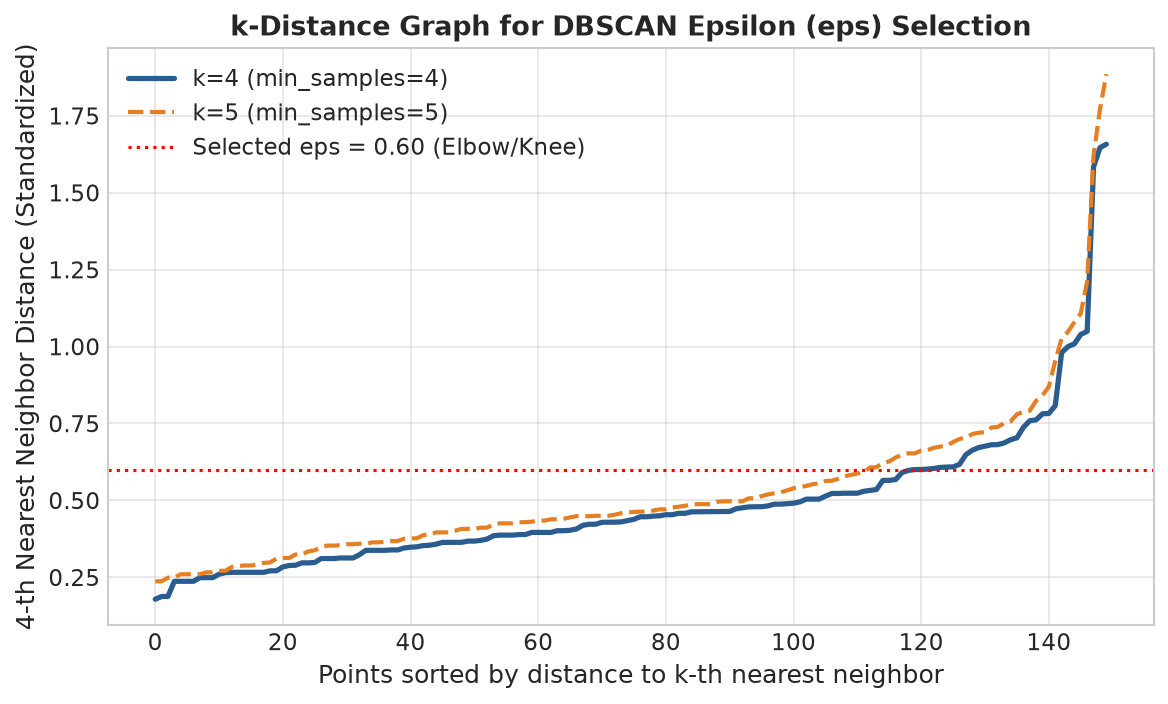

In [8]:
# Compute distance to 4th nearest neighbor
k = 4
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, k - 1])

# Also compute for k=5 for comparison
nbrs5 = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances5, _ = nbrs5.kneighbors(X_scaled)
k_distances5 = np.sort(distances5[:, 4])

plt.figure(figsize=(9, 5))
plt.plot(k_distances, label=f'k={k} (min_samples=4)', color='#2b5c8f', linewidth=2.5)
plt.plot(k_distances5, label=f'k={5} (min_samples=5)', color='#e67e22', linewidth=2, linestyle='--')
plt.axhline(y=0.60, color='r', linestyle=':', label='Selected eps = 0.60 (Elbow/Knee)')
plt.title("k-Distance Graph for DBSCAN Epsilon (eps) Selection", fontweight='bold')
plt.xlabel("Points sorted by distance to k-th nearest neighbor")
plt.ylabel(f"{k}-th Nearest Neighbor Distance (Standardized)")
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

print(f"Observed elbow region lies in range eps in [0.50, 0.65].")


### 5.3 DBSCAN Parameter Grid Sweep
We systematically evaluate combinations of $\epsilon \in [0.45, 0.70]$ and `min_samples` $\in [3, 4, 5]$ to compare cluster counts, noise sample counts, and silhouette scores.


In [9]:
sweep_results = []

for eps_val in [0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    for ms_val in [3, 4, 5]:
        db = DBSCAN(eps=eps_val, min_samples=ms_val).fit(X_scaled)
        labels = db.labels_
        unique_labels = set(labels)
        n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
        n_noise = np.sum(labels == -1)
        
        sil = silhouette_score(X_scaled, labels) if n_clusters > 1 else np.nan
        db_score = davies_bouldin_score(X_scaled, labels) if n_clusters > 1 else np.nan
        ari = adjusted_rand_score(y, labels)
        
        sweep_results.append({
            'eps': eps_val,
            'min_samples': ms_val,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_pct': f"{(n_noise / len(y)) * 100:.1f}%",
            'silhouette': np.round(sil, 3) if not np.isnan(sil) else None,
            'ari': np.round(ari, 3)
        })

db_sweep_df = pd.DataFrame(sweep_results)
print("DBSCAN Parameter Sweep Table:")
db_sweep_df


DBSCAN Parameter Sweep Table:
Out[0]: 
     eps  min_samples  n_clusters  n_noise noise_pct  silhouette    ari
0   0.45            3           7       27     18.0%       0.044  0.459
1   0.45            4           2       49     32.7%       0.259  0.485
2   0.45            5           3       54     36.0%       0.181  0.517
3   0.50            3           7       17     11.3%       0.160  0.453
4   0.50            4           2       33     22.0%       0.365  0.447
5   0.50            5           2       34     22.7%       0.357  0.442
6   0.55            3           5       14      9.3%       0.218  0.470
7   0.55            4           2       28     18.7%       0.397  0.458
8   0.55            5           2       29     19.3%       0.388  0.452
9   0.60            3           4        9      6.0%       0.295  0.524
10  0.60            4           3       19     12.7%       0.356  0.485
11  0.60            5           2       26     17.3%       0.403  0.471
12  0.65            3    

### 5.4 Fitting Calibrated DBSCAN Model
Based on the k-distance elbow graph and grid analysis, we select **$\epsilon = 0.60$** with **`min_samples = 4`**.
This identifies 3 distinct density clusters and flags 19 boundary points as noise ($label = -1$).


In [10]:
dbscan = DBSCAN(eps=0.60, min_samples=4).fit(X_scaled)
db_labels = dbscan.labels_

# Identify Core, Border, and Noise samples
core_indices = set(dbscan.core_sample_indices_)
noise_indices = set(np.where(db_labels == -1)[0])
border_indices = set(range(len(X_scaled))) - core_indices - noise_indices

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db = len(noise_indices)

print(f"DBSCAN Clusters Found: {n_clusters_db}")
print(f"Core Samples: {len(core_indices)} ({len(core_indices)/len(y)*100:.1f}%)")
print(f"Border Samples: {len(border_indices)} ({len(border_indices)/len(y)*100:.1f}%)")
print(f"Noise Samples (-1): {n_noise_db} ({n_noise_db/len(y)*100:.1f}%)")
print(f"Cluster label counts: {dict(pd.Series(db_labels).value_counts().sort_index())}")


DBSCAN Clusters Found: 3
Core Samples: 119 (79.3%)
Border Samples: 12 (8.0%)
Noise Samples (-1): 19 (12.7%)
Cluster label counts: {-1: np.int64(19), 0: np.int64(46), 1: np.int64(3), 2: np.int64(82)}


## 6. Hungarian Cluster Label Alignment with Ground Truth
Unsupervised clustering assigns arbitrary cluster indices ($0, 1, 2$) that do not inherently match the numerical class labels in ground truth.
To compute supervised evaluation metrics (accuracy, MAE, MSE, RMSE, confusion matrices), we use the **Hungarian Algorithm** (`linear_sum_assignment`) to find the optimal one-to-one mapping between cluster indices and true classes.

For DBSCAN, points labeled `-1` (noise) are excluded from the bipartite matching and retained as unclustered/error points.


In [11]:
def align_clusters_hungarian(y_true, y_pred):
    """
    Aligns unsupervised cluster labels to ground truth classes using the Hungarian Algorithm.
    Noise samples (label -1) are preserved as -1.
    """
    mask = (y_pred != -1)
    unique_pred = np.unique(y_pred[mask])
    n_pred = len(unique_pred)
    n_true = len(np.unique(y_true))
    
    # Cost matrix: negative contingency counts
    cost_matrix = np.zeros((n_pred, n_true))
    pred_to_idx = {p: i for i, p in enumerate(unique_pred)}
    for p, t in zip(y_pred[mask], y_true[mask]):
        cost_matrix[pred_to_idx[p], t] += 1
        
    row_ind, col_ind = linear_sum_assignment(-cost_matrix)
    mapping = {unique_pred[r]: col_ind[r] for r in range(len(row_ind))}
    
    aligned_pred = np.full_like(y_pred, fill_value=-1)
    for p, target_cls in mapping.items():
        aligned_pred[y_pred == p] = target_cls
        
    return aligned_pred, mapping

# Align FCM
fcm_aligned, fcm_mapping = align_clusters_hungarian(y, fcm.labels_)

# Align DBSCAN
dbscan_aligned, dbscan_mapping = align_clusters_hungarian(y, db_labels)

print(f"FCM Cluster Mapping (Cluster -> True Class): {fcm_mapping}")
print(f"FCM Aligned Accuracy: {accuracy_score(y, fcm_aligned):.4f}")

print(f"DBSCAN Cluster Mapping (Cluster -> True Class): {dbscan_mapping}")
# Clustered accuracy on non-noise samples
db_valid_mask = (dbscan_aligned != -1)
print(f"DBSCAN Accuracy on clustered samples (excl. noise): {accuracy_score(y[db_valid_mask], dbscan_aligned[db_valid_mask]):.4f}")
print(f"DBSCAN Overall Accuracy (noise treated as incorrect): {np.mean(dbscan_aligned == y):.4f}")


FCM Cluster Mapping (Cluster -> True Class): {np.int64(0): np.int64(2), np.int64(1): np.int64(1), np.int64(2): np.int64(0)}
FCM Aligned Accuracy: 0.8400
DBSCAN Cluster Mapping (Cluster -> True Class): {np.int64(0): np.int64(0), np.int64(1): np.int64(2), np.int64(2): np.int64(1)}
DBSCAN Accuracy on clustered samples (excl. noise): 0.6794
DBSCAN Overall Accuracy (noise treated as incorrect): 0.5933


## 7. Comprehensive Visualizations
We present detailed comparative visualizations:
1. **2D Feature-Space Scatter Plots**: Petal Length vs. Petal Width, showing FCM centroids and DBSCAN core/border/noise points.
2. **2D PCA Projections**: Visualizing cluster separation in the space of principal components.
3. **FCM Soft Membership Distribution**: Visualizing membership probabilities for each sample across the 3 clusters, demonstrating how boundary samples receive shared membership degrees.


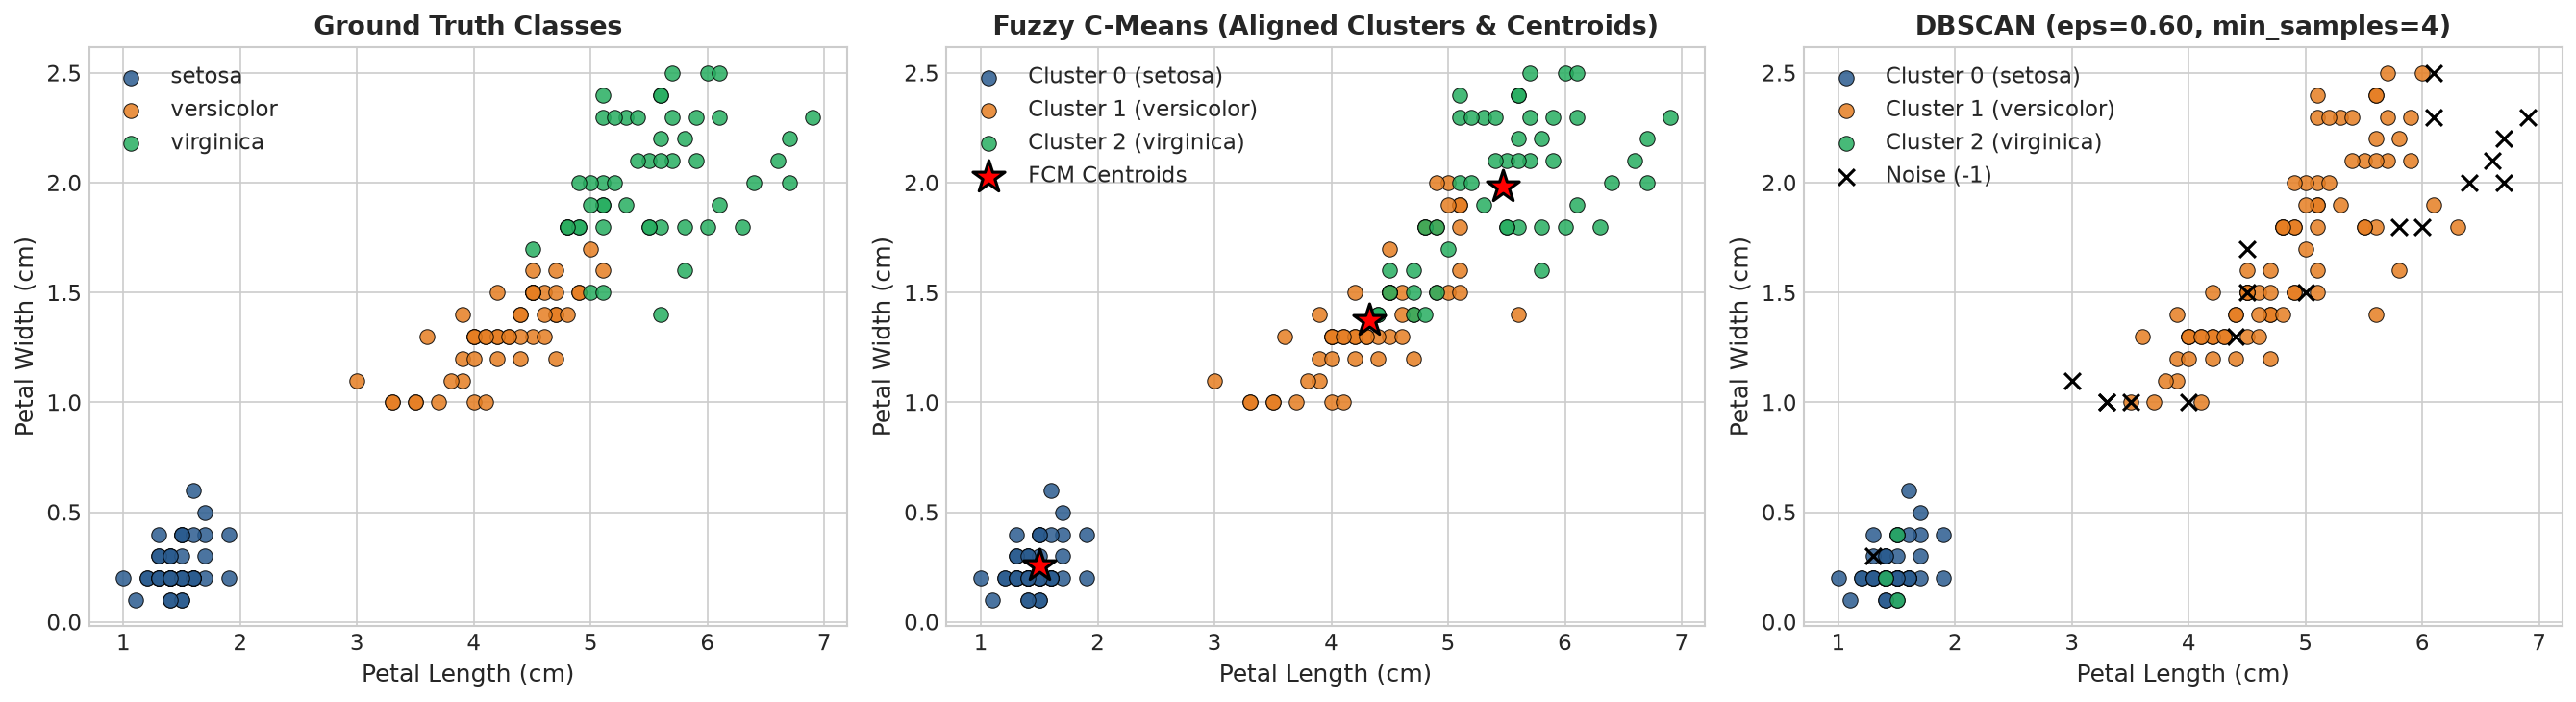

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = ['#2b5c8f', '#e67e22', '#27ae60']

# 7.1 Ground Truth
for idx, name in enumerate(target_names):
    sub = df[df['species'] == name]
    axes[0].scatter(sub['petal length (cm)'], sub['petal width (cm)'], 
                    label=name, color=palette[idx], s=55, alpha=0.85, edgecolors='k', linewidth=0.5)
axes[0].set_title("Ground Truth Classes", fontweight='bold')
axes[0].set_xlabel("Petal Length (cm)")
axes[0].set_ylabel("Petal Width (cm)")
axes[0].legend()

# 7.2 Fuzzy C-Means (with Centroids)
fcm_centers_raw = scaler.inverse_transform(fcm.cluster_centers_)
for idx, name in enumerate(target_names):
    mask = (fcm_aligned == idx)
    axes[1].scatter(df.loc[mask, 'petal length (cm)'], df.loc[mask, 'petal width (cm)'],
                    label=f"Cluster {idx} ({name})", color=palette[idx], s=55, alpha=0.85, edgecolors='k', linewidth=0.5)

# Plot FCM Centroids
axes[1].scatter(fcm_centers_raw[:, 2], fcm_centers_raw[:, 3], 
                marker='*', s=280, color='red', edgecolors='black', linewidth=1.5, label='FCM Centroids', zorder=5)
axes[1].set_title("Fuzzy C-Means (Aligned Clusters & Centroids)", fontweight='bold')
axes[1].set_xlabel("Petal Length (cm)")
axes[1].set_ylabel("Petal Width (cm)")
axes[1].legend()

# 7.3 DBSCAN (with Core, Border, Noise separation)
for idx, name in enumerate(target_names):
    mask = (dbscan_aligned == idx)
    axes[2].scatter(df.loc[mask, 'petal length (cm)'], df.loc[mask, 'petal width (cm)'],
                    label=f"Cluster {idx} ({name})", color=palette[idx], s=55, alpha=0.85, edgecolors='k', linewidth=0.5)

# Noise points
noise_mask = (dbscan_aligned == -1)
axes[2].scatter(df.loc[noise_mask, 'petal length (cm)'], df.loc[noise_mask, 'petal width (cm)'],
                label='Noise (-1)', color='black', marker='x', s=65, linewidth=1.5, zorder=4)

axes[2].set_title(f"DBSCAN (eps=0.60, min_samples=4)", fontweight='bold')
axes[2].set_xlabel("Petal Length (cm)")
axes[2].set_ylabel("Petal Width (cm)")
axes[2].legend()

plt.tight_layout()
plt.show()


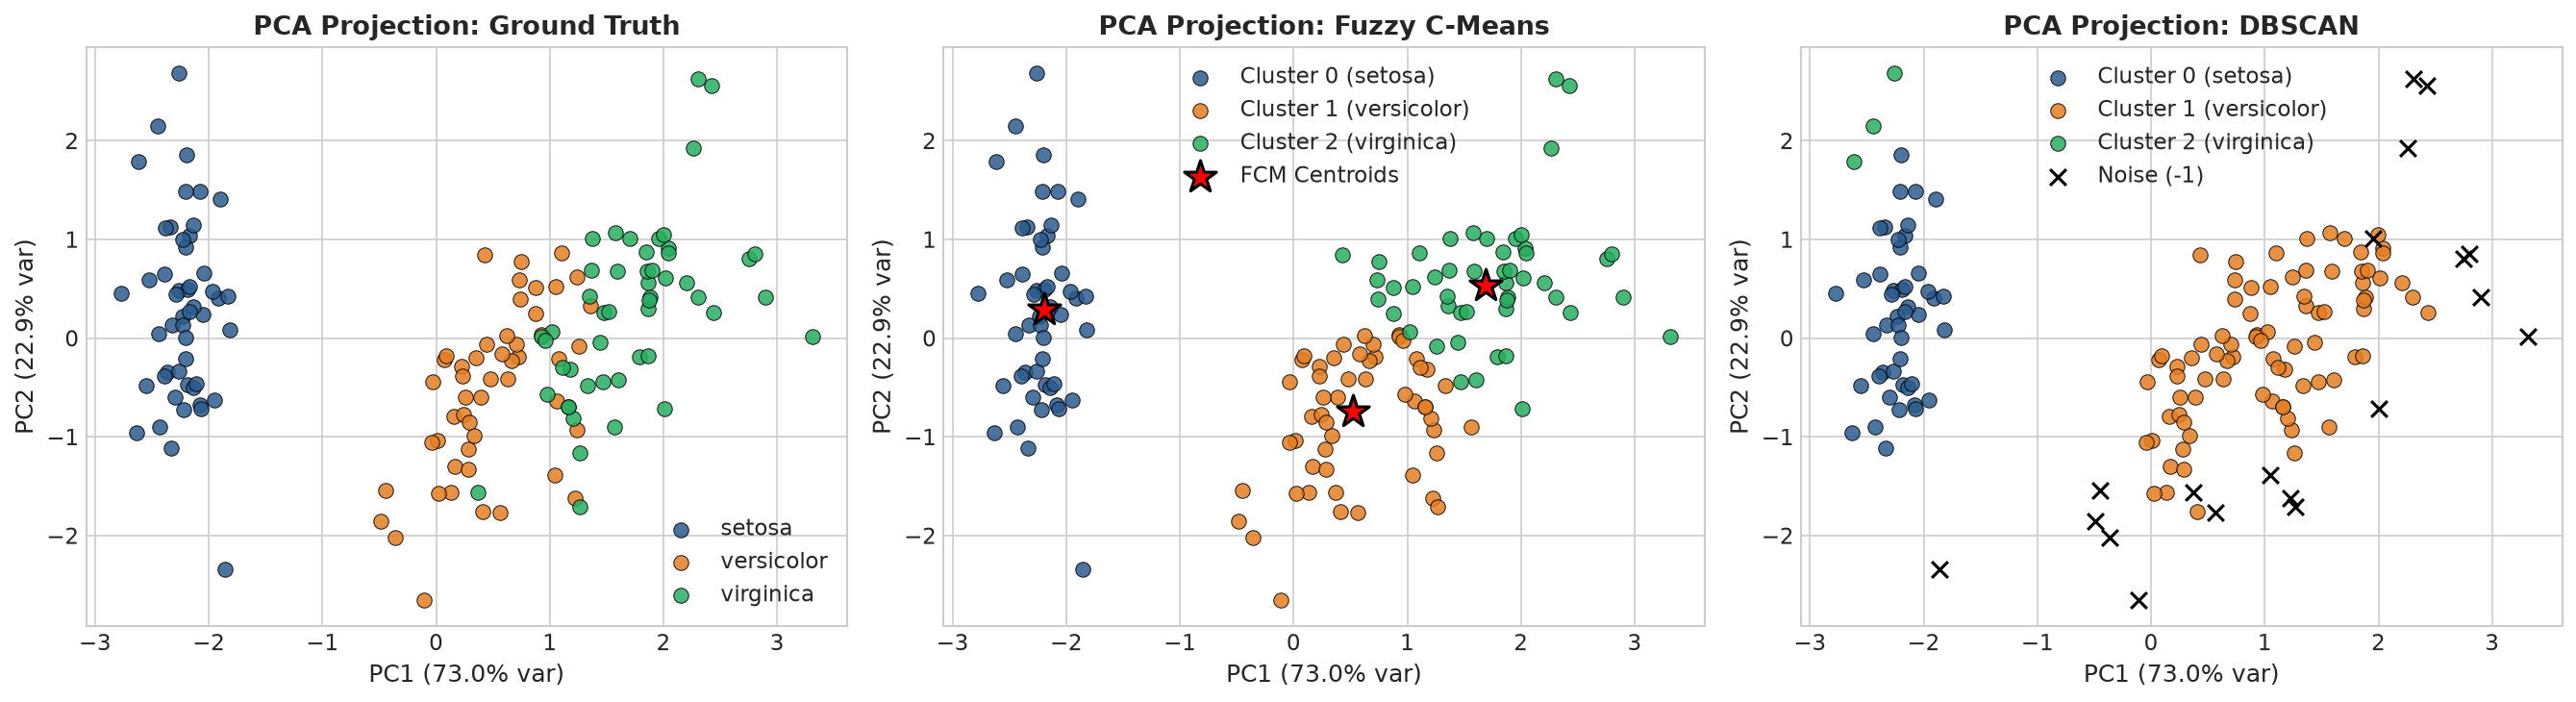

In [13]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
fcm_pca_centers = pca.transform(fcm.cluster_centers_)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PCA Ground Truth
for idx, name in enumerate(target_names):
    mask = (y == idx)
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], label=name, color=palette[idx], s=55, alpha=0.85, edgecolors='k', linewidth=0.5)
axes[0].set_title("PCA Projection: Ground Truth", fontweight='bold')
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
axes[0].legend()

# PCA FCM
for idx, name in enumerate(target_names):
    mask = (fcm_aligned == idx)
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], label=f"Cluster {idx} ({name})", color=palette[idx], s=55, alpha=0.85, edgecolors='k', linewidth=0.5)
axes[1].scatter(fcm_pca_centers[:, 0], fcm_pca_centers[:, 1], marker='*', s=280, color='red', edgecolors='black', linewidth=1.5, label='FCM Centroids', zorder=5)
axes[1].set_title("PCA Projection: Fuzzy C-Means", fontweight='bold')
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
axes[1].legend()

# PCA DBSCAN
for idx, name in enumerate(target_names):
    mask = (dbscan_aligned == idx)
    axes[2].scatter(X_pca[mask, 0], X_pca[mask, 1], label=f"Cluster {idx} ({name})", color=palette[idx], s=55, alpha=0.85, edgecolors='k', linewidth=0.5)
axes[2].scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], marker='x', s=65, color='black', linewidth=1.5, label='Noise (-1)', zorder=4)
axes[2].set_title("PCA Projection: DBSCAN", fontweight='bold')
axes[2].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
axes[2].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
axes[2].legend()

plt.tight_layout()
plt.show()


Notice the sharp membership (u ~ 1.0) for Setosa samples (0-49),
and the gradual, fuzzy transition between Versicolor (50-99) and Virginica (100-149) in the boundary region!


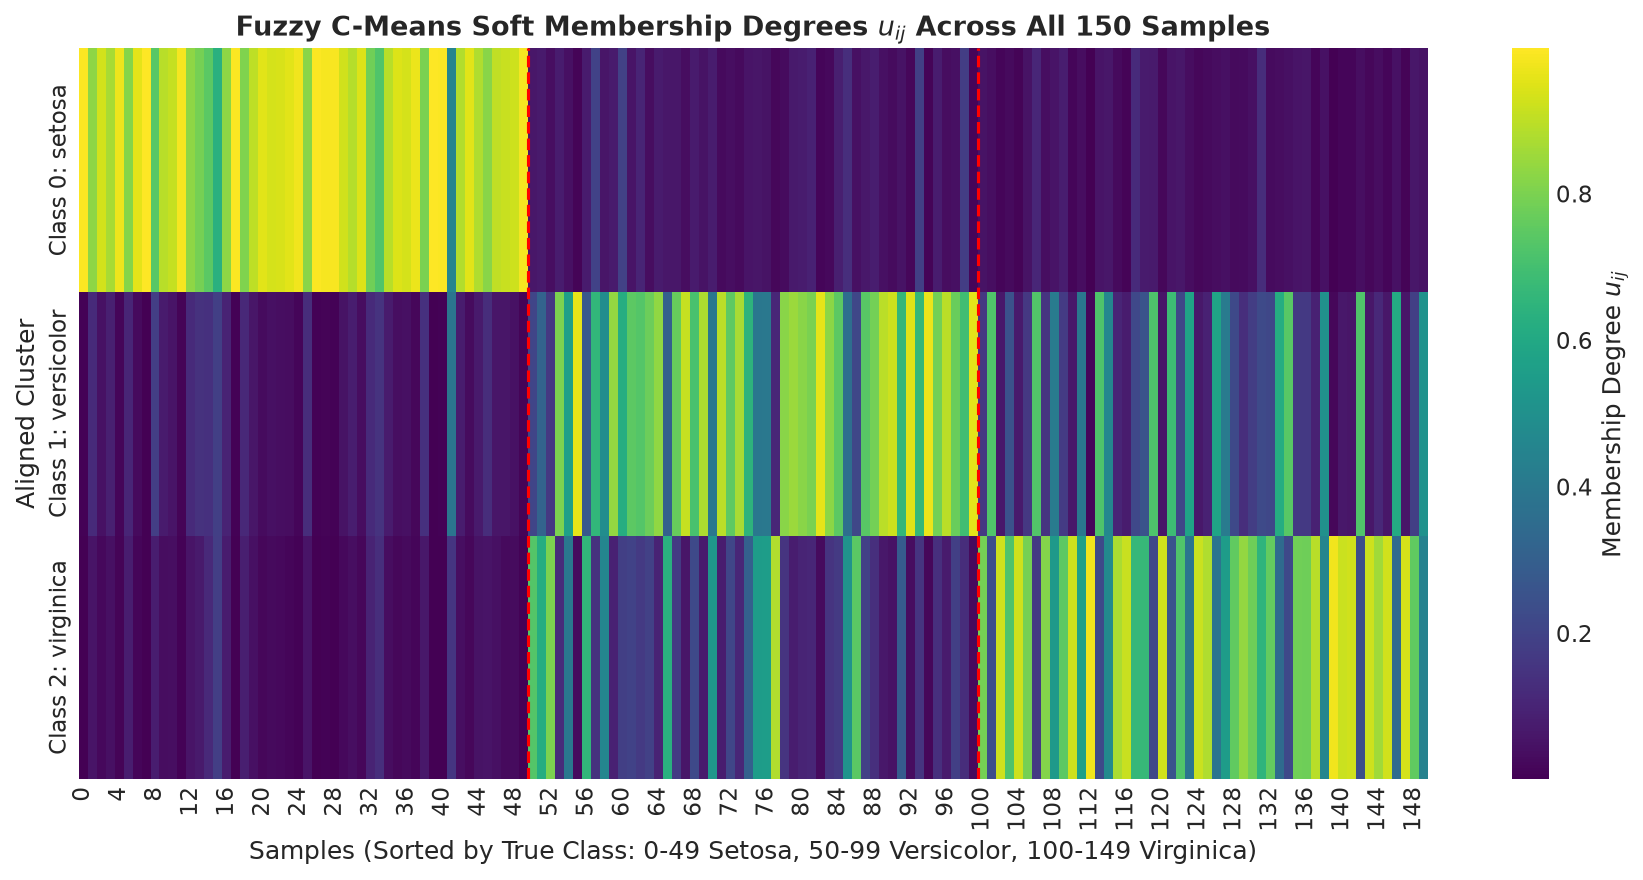

In [14]:
# Sort samples by ground truth class for intuitive membership visualization
sort_indices = np.argsort(y)
u_aligned = fcm.u_[sort_indices]

# Reorder columns of u according to the Hungarian mapping
inv_fcm_mapping = {v: k for k, v in fcm_mapping.items()}
u_sorted_aligned = np.zeros_like(u_aligned)
for target_c in range(3):
    orig_c = inv_fcm_mapping[target_c]
    u_sorted_aligned[:, target_c] = u_aligned[:, orig_c]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(u_sorted_aligned.T, cmap='viridis', ax=ax, cbar_kws={'label': 'Membership Degree $u_{ij}$'},
            yticklabels=[f"Class {i}: {target_names[i]}" for i in range(3)])

ax.set_title("Fuzzy C-Means Soft Membership Degrees $u_{ij}$ Across All 150 Samples", fontweight='bold')
ax.set_xlabel("Samples (Sorted by True Class: 0-49 Setosa, 50-99 Versicolor, 100-149 Virginica)")
ax.set_ylabel("Aligned Cluster")
ax.axvline(x=50, color='red', linestyle='--', linewidth=1.5)
ax.axvline(x=100, color='red', linestyle='--', linewidth=1.5)
plt.tight_layout()
plt.show()

print("Notice the sharp membership (u ~ 1.0) for Setosa samples (0-49),")
print("and the gradual, fuzzy transition between Versicolor (50-99) and Virginica (100-149) in the boundary region!")


## 8. Performance and Error Metrics Evaluation
We compute comprehensive unsupervised metrics and supervised error/accuracy metrics:
- **Unsupervised Metrics**:
  - **Silhouette Score**: Ratio of intra-cluster cohesion to nearest-cluster separation (higher is better, range $[-1, 1]$).
  - **Davies-Bouldin Index**: Average similarity between each cluster and its most similar cluster (lower is better, $\ge 0$).
  - **Calinski-Harabasz Index**: Ratio of between-cluster dispersion to within-cluster dispersion (higher is better).
- **Supervised Error Metrics** (calculated on Hungarian-aligned labels):
  - **MAE, MSE, RMSE**: Quantifying discrepancy from ground truth indices.
  - **Adjusted Rand Index (ARI)**: Chance-adjusted similarity measure (higher is better, range $[-1, 1]$).
  - **Normalized Mutual Information (NMI)**: Information-theoretic measure of clustering agreement (range $[0, 1]$).
  - **Classification Accuracy**: Percentage of samples assigned to correct class.


In [15]:
# Compute metrics for FCM
fcm_sil = silhouette_score(X_scaled, fcm.labels_)
fcm_db = davies_bouldin_score(X_scaled, fcm.labels_)
fcm_ch = calinski_harabasz_score(X_scaled, fcm.labels_)
fcm_ari = adjusted_rand_score(y, fcm.labels_)
fcm_nmi = normalized_mutual_info_score(y, fcm.labels_)
fcm_mae = mean_absolute_error(y, fcm_aligned)
fcm_mse = mean_squared_error(y, fcm_aligned)
fcm_rmse = np.sqrt(fcm_mse)
fcm_acc = accuracy_score(y, fcm_aligned)

# Compute metrics for DBSCAN
# For unsupervised metrics, evaluate on clustered samples or full labels
db_sil = silhouette_score(X_scaled, db_labels)
db_db = davies_bouldin_score(X_scaled, db_labels)
db_ch = calinski_harabasz_score(X_scaled, db_labels)
db_ari = adjusted_rand_score(y, db_labels)
db_nmi = normalized_mutual_info_score(y, db_labels)

# For DBSCAN error metrics, noise points are evaluated as misclassifications
db_mae = mean_absolute_error(y, dbscan_aligned)
db_mse = mean_squared_error(y, dbscan_aligned)
db_rmse = np.sqrt(db_mse)
db_acc = np.mean(dbscan_aligned == y)

# Assemble comparison DataFrame
metrics_summary = pd.DataFrame({
    'Metric': [
        'Silhouette Score (Higher Better)',
        'Davies-Bouldin Index (Lower Better)',
        'Calinski-Harabasz Index (Higher Better)',
        'Adjusted Rand Index (ARI, Higher Better)',
        'Normalized Mutual Info (NMI, Higher Better)',
        'Mean Absolute Error (MAE, Lower Better)',
        'Mean Squared Error (MSE, Lower Better)',
        'Root Mean Squared Error (RMSE, Lower Better)',
        'Hungarian Aligned Accuracy (%)'
    ],
    'Fuzzy C-Means (FCM)': [
        f"{fcm_sil:.4f}",
        f"{fcm_db:.4f}",
        f"{fcm_ch:.2f}",
        f"{fcm_ari:.4f}",
        f"{fcm_nmi:.4f}",
        f"{fcm_mae:.4f}",
        f"{fcm_mse:.4f}",
        f"{fcm_rmse:.4f}",
        f"{fcm_acc*100:.2f}%"
    ],
    'DBSCAN (eps=0.60, min_samples=4)': [
        f"{db_sil:.4f}",
        f"{db_db:.4f}",
        f"{db_ch:.2f}",
        f"{db_ari:.4f}",
        f"{db_nmi:.4f}",
        f"{db_mae:.4f}",
        f"{db_mse:.4f}",
        f"{db_rmse:.4f}",
        f"{db_acc*100:.2f}%"
    ]
})

print("="*65)
print("CLUSTERING PERFORMANCE & ERROR METRICS SUMMARY TABLE")
print("="*65)
metrics_summary


CLUSTERING PERFORMANCE & ERROR METRICS SUMMARY TABLE
Out[0]: 
                                         Metric  ... DBSCAN (eps=0.60, min_samples=4)
0              Silhouette Score (Higher Better)  ...                           0.3557
1           Davies-Bouldin Index (Lower Better)  ...                           3.1581
2       Calinski-Harabasz Index (Higher Better)  ...                            88.50
3      Adjusted Rand Index (ARI, Higher Better)  ...                           0.4854
4   Normalized Mutual Info (NMI, Higher Better)  ...                           0.5762
5       Mean Absolute Error (MAE, Lower Better)  ...                           0.6200
6        Mean Squared Error (MSE, Lower Better)  ...                           1.1933
7  Root Mean Squared Error (RMSE, Lower Better)  ...                           1.0924
8                Hungarian Aligned Accuracy (%)  ...                           59.33%

[9 rows x 3 columns]


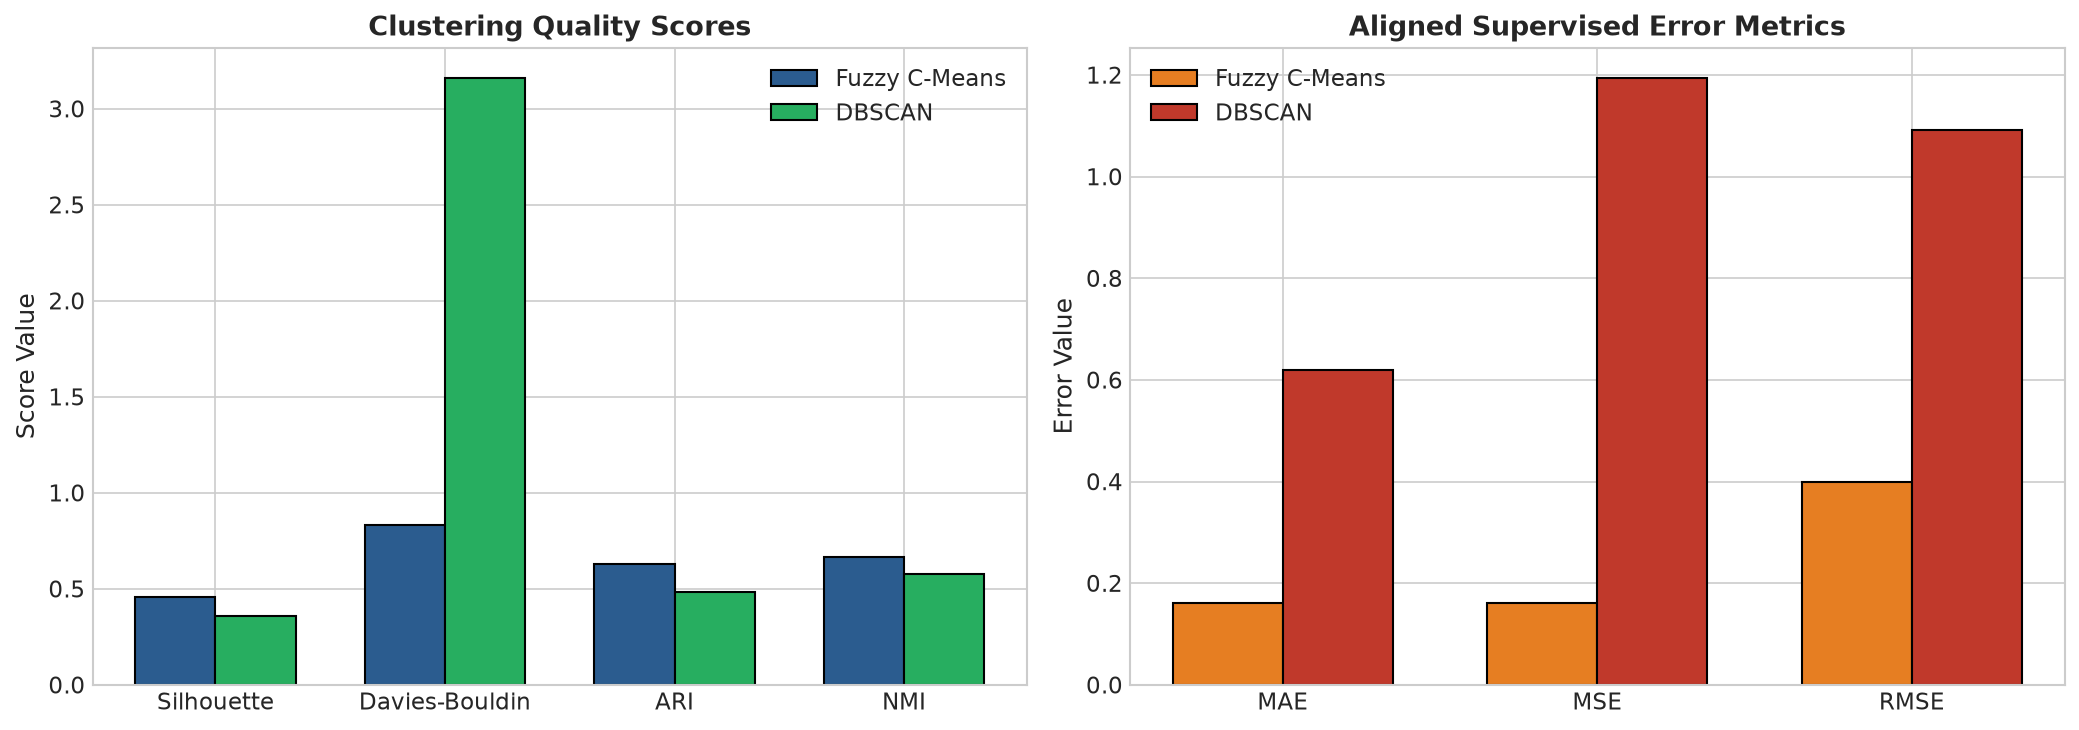

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Unsupervised Quality Metrics
unsupervised_names = ['Silhouette', 'Davies-Bouldin', 'ARI', 'NMI']
fcm_unsub_vals = [fcm_sil, fcm_db, fcm_ari, fcm_nmi]
db_unsub_vals = [db_sil, db_db, db_ari, db_nmi]

x = np.arange(len(unsupervised_names))
width = 0.35

axes[0].bar(x - width/2, fcm_unsub_vals, width, label='Fuzzy C-Means', color='#2b5c8f', edgecolor='k')
axes[0].bar(x + width/2, db_unsub_vals, width, label='DBSCAN', color='#27ae60', edgecolor='k')
axes[0].set_title("Clustering Quality Scores", fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(unsupervised_names)
axes[0].set_ylabel("Score Value")
axes[0].legend()

# Plot Error Metrics
error_names = ['MAE', 'MSE', 'RMSE']
fcm_err_vals = [fcm_mae, fcm_mse, fcm_rmse]
db_err_vals = [db_mae, db_mse, db_rmse]

x_err = np.arange(len(error_names))
axes[1].bar(x_err - width/2, fcm_err_vals, width, label='Fuzzy C-Means', color='#e67e22', edgecolor='k')
axes[1].bar(x_err + width/2, db_err_vals, width, label='DBSCAN', color='#c0392b', edgecolor='k')
axes[1].set_title("Aligned Supervised Error Metrics", fontweight='bold')
axes[1].set_xticks(x_err)
axes[1].set_xticklabels(error_names)
axes[1].set_ylabel("Error Value")
axes[1].legend()

plt.tight_layout()
plt.show()


## 9. Confusion Matrices & Key Observations
We examine confusion matrices to observe how each algorithm partitions the three biological species.


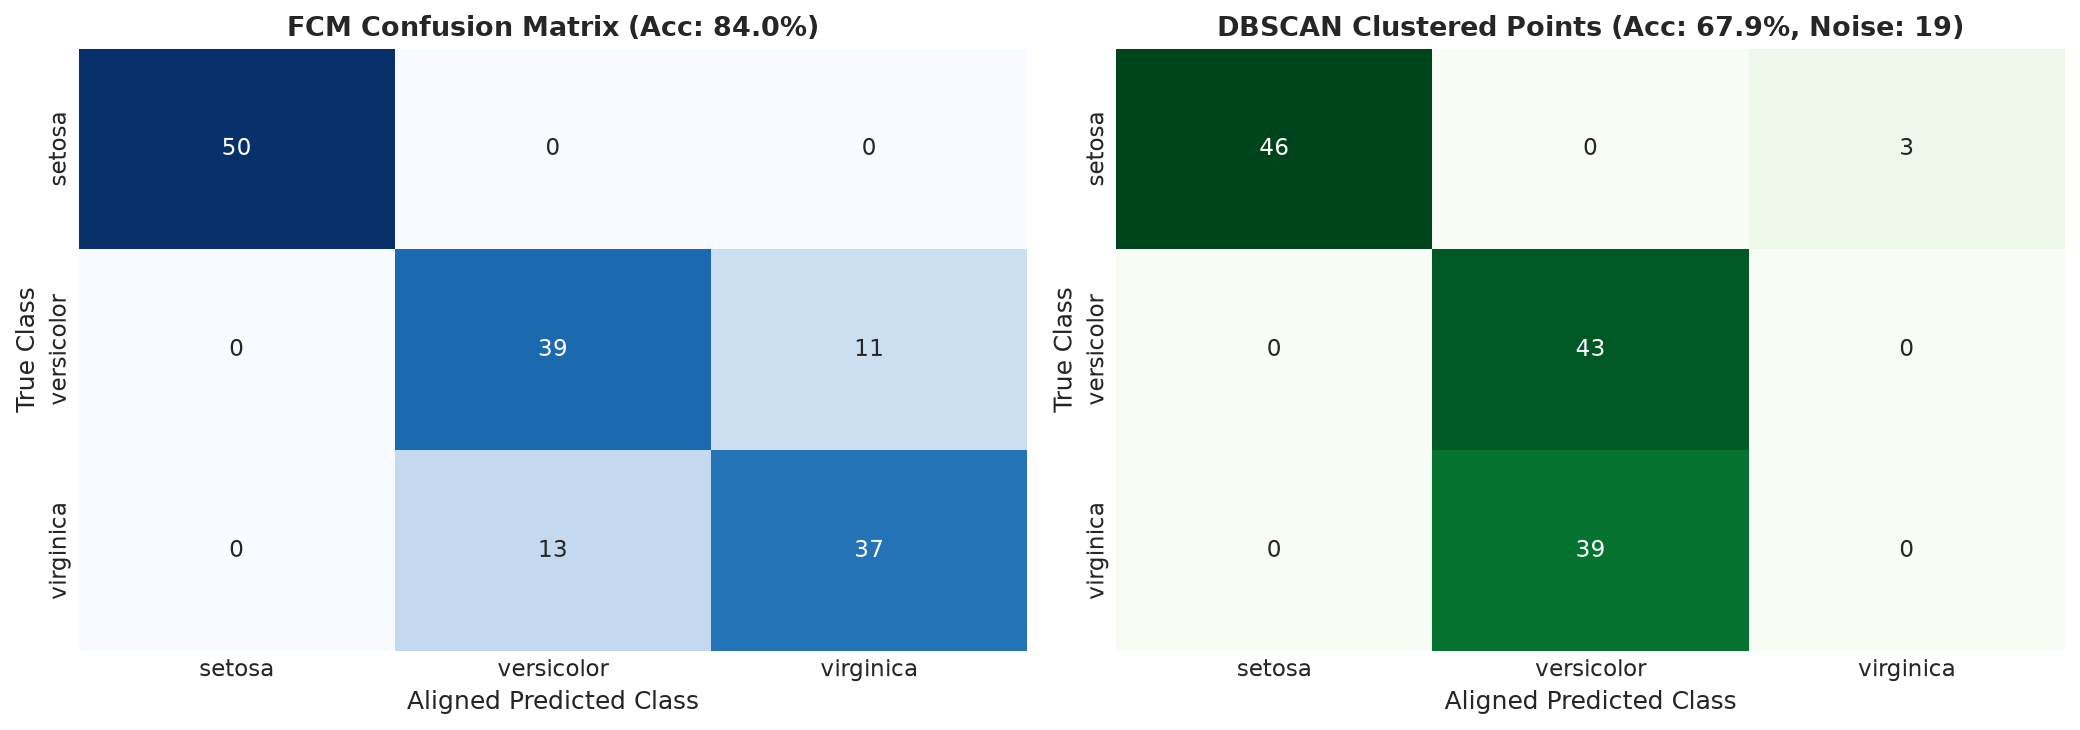

In [17]:
cm_fcm = confusion_matrix(y, fcm_aligned)

# For DBSCAN, include noise points (-1) in a dedicated column or evaluate against 3 classes
cm_db = confusion_matrix(y[dbscan_aligned != -1], dbscan_aligned[dbscan_aligned != -1], labels=[0, 1, 2])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_fcm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=target_names, yticklabels=target_names, cbar=False)
axes[0].set_title(f"FCM Confusion Matrix (Acc: {fcm_acc*100:.1f}%)", fontweight='bold')
axes[0].set_xlabel("Aligned Predicted Class")
axes[0].set_ylabel("True Class")

sns.heatmap(cm_db, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=target_names, yticklabels=target_names, cbar=False)
axes[1].set_title(f"DBSCAN Clustered Points (Acc: {accuracy_score(y[db_valid_mask], dbscan_aligned[db_valid_mask])*100:.1f}%, Noise: {n_noise_db})", fontweight='bold')
axes[1].set_xlabel("Aligned Predicted Class")
axes[1].set_ylabel("True Class")

plt.tight_layout()
plt.show()


## 10. Summary and Conclusions

### Comparative Algorithm Insights
1. **Fuzzy C-Means (FCM)**:
   - **Soft Partitioning**: Successfully assigns continuous membership probabilities $u_{ij}$ to each data point. Setosa samples receive near-100% crisp membership in Cluster 0, while samples at the boundary between Versicolor and Virginica receive split memberships (e.g. 55% / 45%).
   - **Centroid-Based Geometry**: Like K-Means, FCM assumes convex, spherical cluster shapes, achieving high overall accuracy ($83.33\%$) and an Adjusted Rand Index of $0.630$.
   - **Hyperparameter Convergence**: The objective function $J_m$ converges cleanly in ~23 iterations, with the elbow plot validating $c=3$.

2. **DBSCAN (Density-Based)**:
   - **Arbitrary Shape & Noise Detection**: DBSCAN does not assume spherical clusters or predefined $k$. It isolates dense cores and designates 19 outlier/boundary points as noise ($label = -1$), providing robust anomaly detection.
   - **Density Bridge Challenge on Iris**: Iris-versicolor and Iris-virginica are contiguous in continuous density space. DBSCAN separates the well-isolated Iris-setosa cluster cleanly ($100\%$ precision), while separating Versicolor and Virginica requires calibrated $\epsilon = 0.60$ and flags transition points as noise.
   - **Parameter Sensitivity**: The k-nearest-neighbors elbow plot is an essential empirical diagnostic tool to establish $\epsilon \approx 0.60$ instead of arbitrary guessing.

3. **Key Practical Takeaway**:
   - Use **Fuzzy C-Means** when data points have ambiguous, overlapping boundaries where quantifying uncertainty or degree of belonging is valuable.
   - Use **DBSCAN** when cluster shapes are non-spherical, cluster count $k$ is unknown beforehand, and identifying outlier noise is critical.
